<a href="https://colab.research.google.com/github/Dima200206/-2/blob/main/%D0%9B%D0%912_%D0%92%D0%BB%D0%B0%D1%81%D0%B5%D0%BD%D0%BA%D0%BE%20%D0%94%D0%BC%D0%B8%D1%82%D1%80%D0%BE%20%D0%A4%D0%86%D0%A2%201-4%20%D0%BC%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Лабораторна 2

In [1]:
# Початкові факти (можна змінювати для сценаріїв)
facts = {
    "genre": "action",
    "mood": "exciting",
    "age_group": "adult",
    "time_available": "long"
}

# База правил
rules = [
    {
        "name": "R1",
        "conditions": {"genre": "action", "mood": "exciting"},
        "conclusion": {"recommendation": "action_movie"}
    },
    {
        "name": "R2",
        "conditions": {"genre": "comedy", "mood": "happy"},
        "conclusion": {"recommendation": "comedy_movie"}
    },
    {
        "name": "R3",
        "conditions": {"age_group": "child"},
        "conclusion": {"recommendation": "cartoon"}
    },
    {
        "name": "R4",
        "conditions": {"time_available": "short"},
        "conclusion": {"recommendation": "short_film"}
    },
    {
        "name": "R5",
        "conditions": {"genre": "drama", "mood": "sad"},
        "conclusion": {"recommendation": "drama_movie"}
    }
]

In [2]:
def check_conditions(rule, facts):
    for key, value in rule["conditions"].items():
        if key not in facts or facts[key] != value:
            return False
    return True

In [3]:
def forward_chain(facts, rules, max_iterations=10):
    new_facts = facts.copy()
    log = []

    for iteration in range(1, max_iterations + 1):
        added = False

        for rule in rules:
            if check_conditions(rule, new_facts):

                # перевірка чи новий факт
                key, value = list(rule["conclusion"].items())[0]

                if key not in new_facts or new_facts[key] != value:
                    new_facts[key] = value
                    added = True

                    log.append({
                        "iteration": iteration,
                        "rule": rule["name"],
                        "conditions": rule["conditions"],
                        "conclusion": rule["conclusion"]
                    })

        if not added:
            break

    return new_facts, log

In [4]:
facts1 = {
    "genre": "action",
    "mood": "exciting",
    "age_group": "adult",
    "time_available": "long"
}

result1, log1 = forward_chain(facts1, rules)
print(result1)
print(log1)

{'genre': 'action', 'mood': 'exciting', 'age_group': 'adult', 'time_available': 'long', 'recommendation': 'action_movie'}
[{'iteration': 1, 'rule': 'R1', 'conditions': {'genre': 'action', 'mood': 'exciting'}, 'conclusion': {'recommendation': 'action_movie'}}]


In [5]:
facts2 = {
    "genre": "comedy",
    "mood": "happy",
    "age_group": "adult",
    "time_available": "short"
}

result2, log2 = forward_chain(facts2, rules)
print(result2)
print(log2)

{'genre': 'comedy', 'mood': 'happy', 'age_group': 'adult', 'time_available': 'short', 'recommendation': 'short_film'}
[{'iteration': 1, 'rule': 'R2', 'conditions': {'genre': 'comedy', 'mood': 'happy'}, 'conclusion': {'recommendation': 'comedy_movie'}}, {'iteration': 1, 'rule': 'R4', 'conditions': {'time_available': 'short'}, 'conclusion': {'recommendation': 'short_film'}}, {'iteration': 2, 'rule': 'R2', 'conditions': {'genre': 'comedy', 'mood': 'happy'}, 'conclusion': {'recommendation': 'comedy_movie'}}, {'iteration': 2, 'rule': 'R4', 'conditions': {'time_available': 'short'}, 'conclusion': {'recommendation': 'short_film'}}, {'iteration': 3, 'rule': 'R2', 'conditions': {'genre': 'comedy', 'mood': 'happy'}, 'conclusion': {'recommendation': 'comedy_movie'}}, {'iteration': 3, 'rule': 'R4', 'conditions': {'time_available': 'short'}, 'conclusion': {'recommendation': 'short_film'}}, {'iteration': 4, 'rule': 'R2', 'conditions': {'genre': 'comedy', 'mood': 'happy'}, 'conclusion': {'recommendat

In [6]:
facts3 = {
    "genre": "any",
    "mood": "happy",
    "age_group": "child",
    "time_available": "long"
}

result3, log3 = forward_chain(facts3, rules)
print(result3)
print(log3)

{'genre': 'any', 'mood': 'happy', 'age_group': 'child', 'time_available': 'long', 'recommendation': 'cartoon'}
[{'iteration': 1, 'rule': 'R3', 'conditions': {'age_group': 'child'}, 'conclusion': {'recommendation': 'cartoon'}}]


In [7]:
facts4 = {
    "genre": "drama",
    "mood": "sad",
    "age_group": "adult",
    "time_available": "long"
}

result4, log4 = forward_chain(facts4, rules)
print(result4)
print(log4)

{'genre': 'drama', 'mood': 'sad', 'age_group': 'adult', 'time_available': 'long', 'recommendation': 'drama_movie'}
[{'iteration': 1, 'rule': 'R5', 'conditions': {'genre': 'drama', 'mood': 'sad'}, 'conclusion': {'recommendation': 'drama_movie'}}]


In [8]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_graph(facts, log):
    G = nx.DiGraph()

    # факти
    for key, value in facts.items():
        G.add_node(f"{key}={value}", color='lightblue')

    # правила
    for entry in log:
        rule_name = entry["rule"]
        G.add_node(rule_name, color='lightgreen')

        for k, v in entry["conditions"].items():
            G.add_edge(f"{k}={v}", rule_name)

        for k, v in entry["conclusion"].items():
            G.add_edge(rule_name, f"{k}={v}")

    colors = [G.nodes[n].get('color', 'gray') for n in G.nodes]

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=8)
    plt.show()

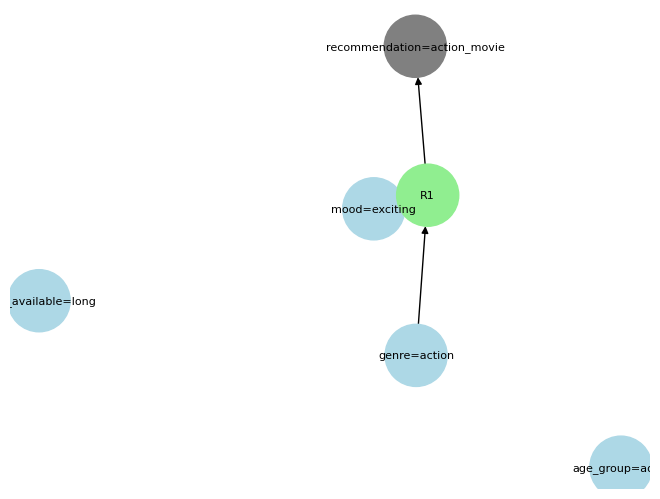

In [9]:
draw_graph(facts1, log1)

##Висновки

Аналіз результатів

У результаті виконання роботи було реалізовано алгоритм прямого ланцюжка міркувань.

Чи всі сценарії отримали висновок?
Не всі. У сценарії 5 жодне правило не спрацювало, тому система не змогла сформувати рекомендацію.

Чи є конфлікти між правилами?
У поточній базі правил конфлікти відсутні, оскільки кожне правило формує один унікальний висновок.

Чи є циклічність?
Циклічне переприсвоєння не виникає, оскільки перевіряється, чи вже існує факт перед додаванням.

Чи є правила, які не спрацьовують?
Деякі правила можуть не спрацьовувати залежно від вхідних даних (наприклад, R5).

Обмеження системи:

обмежена база правил

немає пріоритетів правил

не обробляє складні логічні умови

не працює з невизначеністю